In [1]:
import scipy
from scipy import io, signal
import numpy as np
from matplotlib import pyplot as plt

In [2]:
file_name = "modulated_noisy_audio.wav"

rate, audio_data = scipy.io.wavfile.read(file_name)

In [3]:
def show_fourier(_data, start=0, stop=rate):
    length = len(_data)
    data = _data
    fourier = scipy.fft.fft(data)
    fourier = np.abs(fourier)[round(length * start / rate):round(length * stop / rate)]
    
    freq = np.linspace(0, rate, num=len(data))[round(length * start / rate):round(length * stop / rate)]
    
    plt.figure(1)
    plt.plot(freq, fourier)
    plt.xlabel('Hz')
    plt.ylabel('amplitude')
    plt.show()

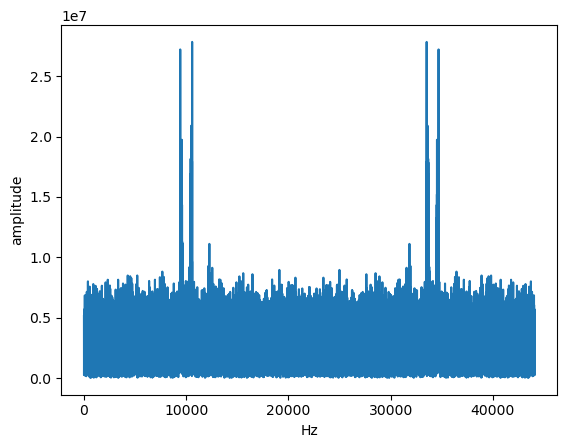

In [4]:
show_fourier(audio_data)

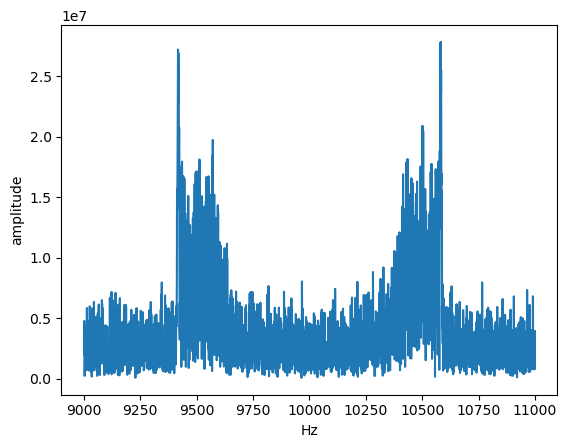

In [5]:
show_fourier(audio_data, start=9_000, stop=11_000)

# Clearly, carrier frequency is 10 KHz

In [6]:
Fc = 10_000

In [7]:
t = np.arange(len(audio_data))
c = np.sin(2 * np.pi * 10_000 * t / rate)
mix = audio_data * c

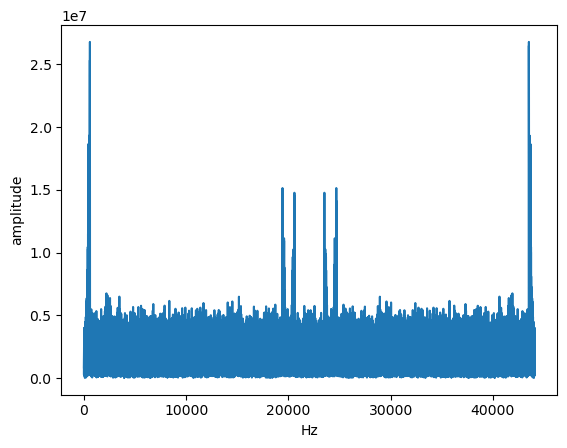

In [8]:
show_fourier(mix)

In [9]:
normal_cutoff = 2_000 / (rate / 2)
b, a = scipy.signal.butter(4, normal_cutoff, btype='low')
low = scipy.signal.lfilter(b, a, mix)

In [10]:
low = 5 * low / np.max(np.abs(low))

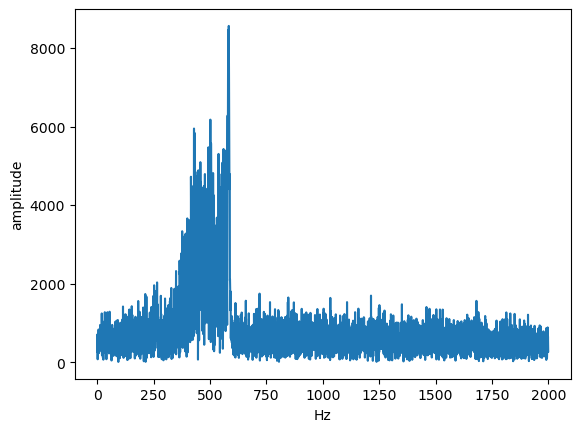

In [11]:
show_fourier(low, stop=2000)
scipy.io.wavfile.write("./all_signals/low.wav", rate, low)

# Noise Filtering

In [12]:
filtered_low = scipy.signal.lfilter(*scipy.signal.butter(4, [400 / (rate / 2), 600 / (rate / 2)], btype='bandpass'), low)

In [13]:
filtered_low = 5 * filtered_low / np.max(np.abs(filtered_low))

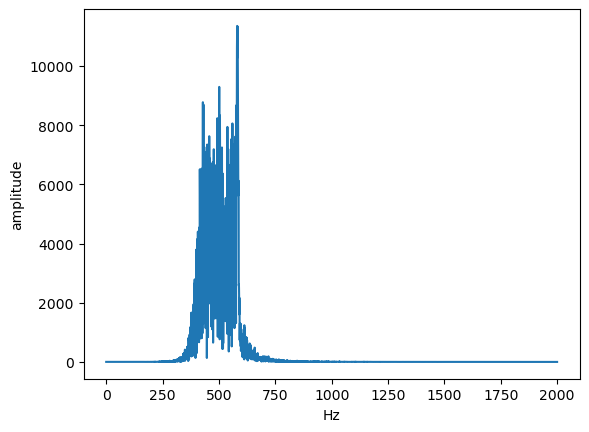

In [14]:
show_fourier(filtered_low, stop=2000)
scipy.io.wavfile.write("./all_signals/filtered_low.wav", rate, filtered_low)

In [15]:
filtered_audio_data1 = scipy.signal.lfilter(*scipy.signal.butter(4, [9250 / (rate / 2), 9750 / (rate / 2)], btype='bandpass'), audio_data)
filtered_audio_data2 = scipy.signal.lfilter(*scipy.signal.butter(4, [10250 / (rate / 2), 10750 / (rate / 2)], btype='bandpass'), audio_data)
filtered_audio_data = filtered_audio_data1 + filtered_audio_data2

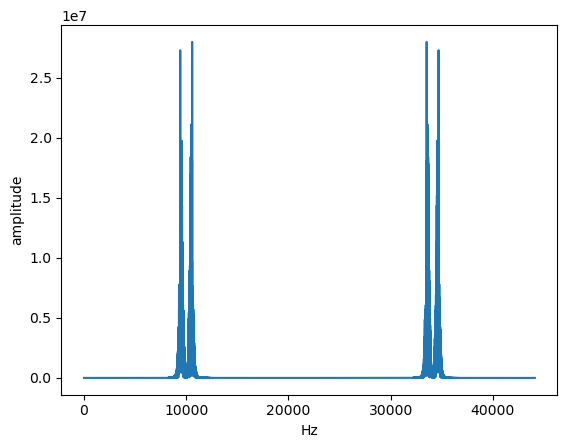

In [16]:
show_fourier(filtered_audio_data)

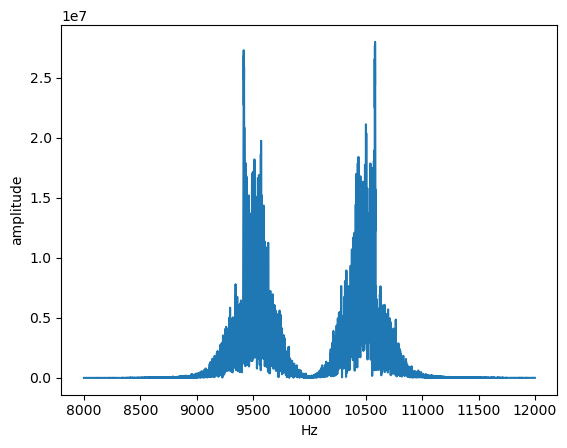

In [17]:
show_fourier(filtered_audio_data, start=8000, stop=12000)

In [18]:
t = np.arange(len(filtered_audio_data))
c = np.sin(2 * np.pi * 10_000 * t / rate)
filtered_mix = filtered_audio_data * c

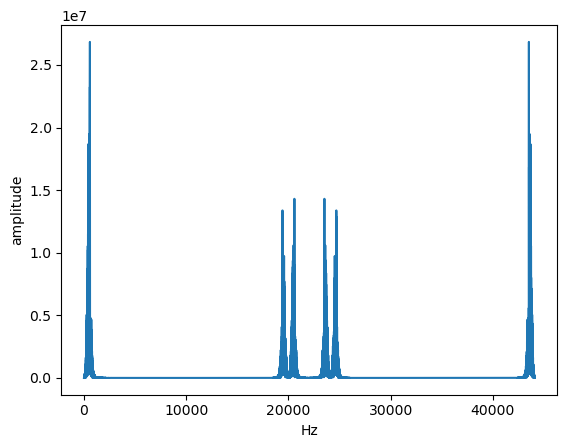

In [19]:
show_fourier(filtered_mix)

In [20]:
normal_cutoff = 2_000 / (rate / 2)
b, a = scipy.signal.butter(4, normal_cutoff, btype='low')
low_filtered = scipy.signal.lfilter(b, a, mix)

In [21]:
low_filtered = 5 * low_filtered / np.max(np.abs(low_filtered))

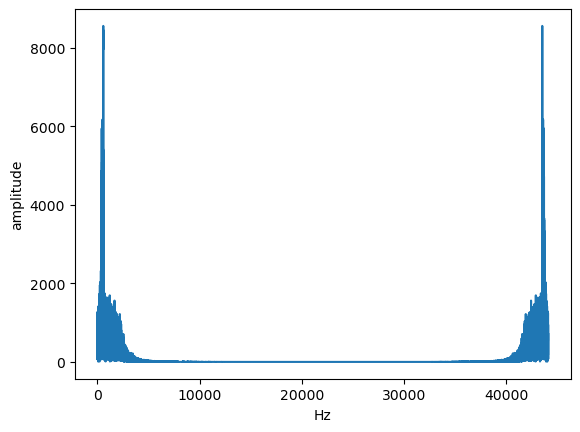

In [22]:
show_fourier(low_filtered)
scipy.io.wavfile.write("./all_signals/low_filtered.wav", rate, low_filtered)

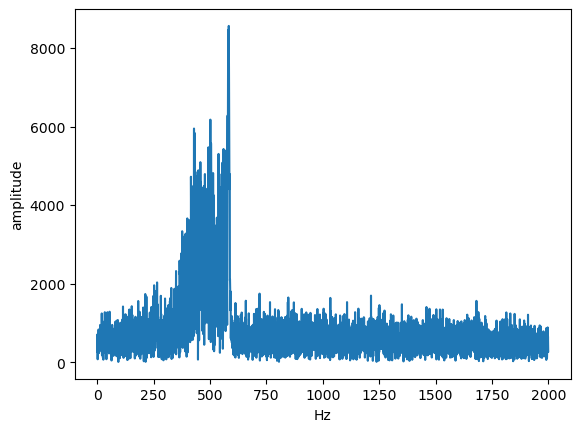

In [23]:
show_fourier(low_filtered, stop=2000)

In [24]:
filtered_filter = scipy.signal.lfilter(*scipy.signal.butter(4, [400 / (rate / 2), 600 / (rate / 2)], btype='bandpass'), low_filtered)

In [25]:
filtered_filter = 5 * filtered_filter / np.max(np.abs(filtered_filter))

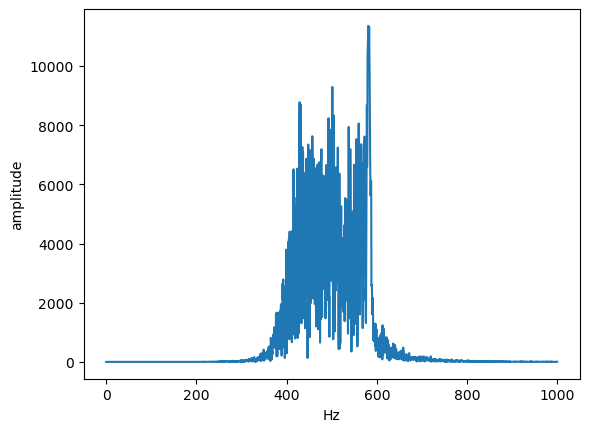

In [26]:
show_fourier(filtered_filter, stop=1000)
scipy.io.wavfile.write("./all_signals/filtered_filter.wav", rate, filtered_filter)

In [27]:
# ultra_filtered1 = scipy.signal.lfilter(*scipy.signal.butter(4, [350 / (rate / 2), 450 / (rate / 2)], btype='bandpass'), audio_data)
# ultra_filtered2 = scipy.signal.lfilter(*scipy.signal.butter(4, [450 / (rate / 2), 550 / (rate / 2)], btype='bandpass'), audio_data)
# ultra_filtered3 = scipy.signal.lfilter(*scipy.signal.butter(4, [550 / (rate / 2), 650 / (rate / 2)], btype='bandpass'), audio_data)
# ultra_filtered = ultra_filtered1 + ultra_filtered2 + ultra_filtered3

In [28]:
# show_fourier(ultra_filtered, stop=1000)
# scipy.io.wavfile.write("./all_signals/ultra_filtered.wav", rate, ultra_filtered)